/tmp/ipykernel_744/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_744/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_744/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_744/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_744/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_744/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_744/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv — non ajouté

PDR (Confirmed)

--- Pure Aloha – Confirmed ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.128960
 800 0.099274
1000 0.069370

--- Slotted Aloha – Confirmed ---
   N    value
  20 0.831843
  50 0.661505
 100 0.501063
 200 0.335821
 400 0.203233
 600 0.144911
 800 0.110120
1000 0.082460

--- CSMA – Confirmed ---
   N    value
  20 0.838203
  50 0.652326
 100 0.488485
 200 0.326227
 400 0.187796
 600 0.126609
 800 0.090799
1000 0.069053

PDR (Unconfirmed)

--- Pure Aloha – Unconfirmed ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.379956
 800 0.268362
1000 0.181818

--- Slotted Aloha – Unconfirmed ---
   N    value
  20 0.886044
  50 0.837298
 100 0.775809
 200 0.670638
 400 0.502486
 600 0.391520
 800 0.288943
1000

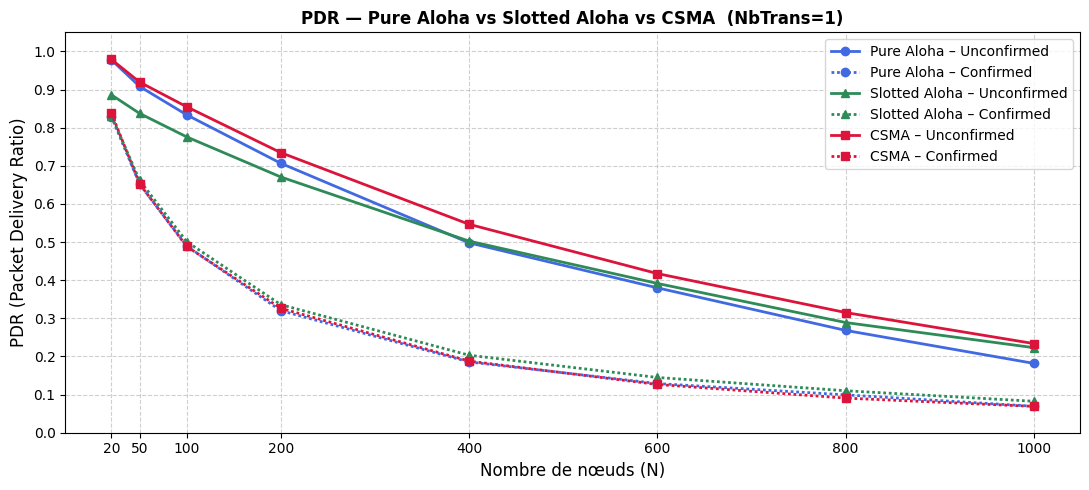

[OK] pdr_3protocols.png sauvegardé


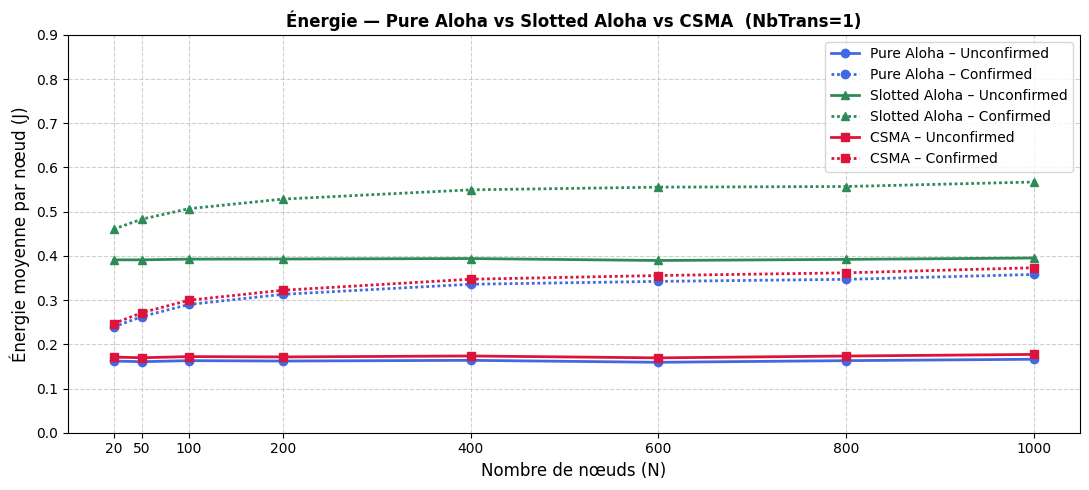

[OK] energy_3protocols.png sauvegardé


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── Chemins ───────────────────────────────────────────────────────────────────
PATHS = {
    "aloha": {
        "unconf": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted": {
        "unconf": os.path.join(BASE, "SlottedAlohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "SlottedAlohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "unconf": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "conf":   os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Couleurs par protocole ────────────────────────────────────────────────────
# Pure Aloha  → royalblue
# Slotted     → seagreen
# CSMA        → crimson
# Unconfirmed → trait plein   ls="-"
# Confirmed   → trait pointillé ls=(0,(1,1))

CURVES = {
    "aloha_unconf":   dict(color="royalblue", marker="o", ls="-",       lw=2, label="Pure Aloha – Unconfirmed"),
    "aloha_conf":     dict(color="royalblue", marker="o", ls=(0,(1,1)), lw=2, label="Pure Aloha – Confirmed"),
    "slotted_unconf": dict(color="seagreen",  marker="^", ls="-",       lw=2, label="Slotted Aloha – Unconfirmed"),
    "slotted_conf":   dict(color="seagreen",  marker="^", ls=(0,(1,1)), lw=2, label="Slotted Aloha – Confirmed"),
    "csma_unconf":    dict(color="crimson",   marker="s", ls="-",       lw=2, label="CSMA – Unconfirmed"),
    "csma_conf":      dict(color="crimson",   marker="s", ls=(0,(1,1)), lw=2, label="CSMA – Confirmed"),
}

LABELS = {k: v["label"] for k, v in CURVES.items()}

# ── Helpers ───────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]]
              .copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_energy_per_node(csv_path, with_csma_energy=False):
    df = _load(csv_path)
    N_dict = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
             df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                 df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


def get_pdr_confirmed(csv_path):
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "numSent")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out


# ── Chargement PDR ────────────────────────────────────────────────────────────
pdr = {}

# Pure Aloha
pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["aloha_unconf"].empty:
    pdr["aloha_unconf"] = get_results(PATHS["aloha"]["unconf"], "LoRa_NS_DER")
pdr["aloha_conf"] = get_pdr_confirmed(PATHS["aloha"]["conf"])

# Slotted Aloha
pdr["slotted_unconf"] = get_results(PATHS["slotted"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["slotted_unconf"].empty:
    pdr["slotted_unconf"] = get_results(PATHS["slotted"]["unconf"], "LoRa_NS_DER")
pdr["slotted_conf"] = get_pdr_confirmed(PATHS["slotted"]["conf"])

# CSMA
pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER", "networkServer")
if pdr["csma_unconf"].empty:
    pdr["csma_unconf"] = get_results(PATHS["csma"]["unconf"], "LoRa_NS_DER")
pdr["csma_conf"] = get_pdr_confirmed(PATHS["csma"]["conf"])

# ── Chargement Énergie ────────────────────────────────────────────────────────
energy = {
    "aloha_unconf":   get_energy_per_node(PATHS["aloha"]["unconf"],   with_csma_energy=False),
    "aloha_conf":     get_energy_per_node(PATHS["aloha"]["conf"],     with_csma_energy=False),
    "slotted_unconf": get_energy_per_node(PATHS["slotted"]["unconf"], with_csma_energy=False),
    "slotted_conf":   get_energy_per_node(PATHS["slotted"]["conf"],   with_csma_energy=False),
    "csma_unconf":    get_energy_per_node(PATHS["csma"]["unconf"],    with_csma_energy=True),
    "csma_conf":      get_energy_per_node(PATHS["csma"]["conf"],      with_csma_energy=True),
}

# ── Affichage console ─────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")
    for scenario, df in data_dict.items():
        print(f"\n--- {LABELS[scenario]} ---")
        if df is None or df.empty:
            print("Aucune donnée")
            continue
        display_df = df.copy()
        display_df["value"] = display_df["value"].round(6)
        if unit:
            display_df["value"] = display_df["value"].astype(str) + f" {unit}"
        print(display_df.to_string(index=False))

# ── Affichage des PDR Confirmed ───────────────────────────────────────────────
pdr_confirmed = {
    "aloha_conf": pdr["aloha_conf"],
    "slotted_conf": pdr["slotted_conf"],
    "csma_conf": pdr["csma_conf"],
}

print_scenario_tables(pdr_confirmed, "PDR (Confirmed)")
pdr_unconfirmed = {
    "aloha_unconf": pdr["aloha_unconf"],
    "slotted_unconf": pdr["slotted_unconf"],
    "csma_unconf": pdr["csma_unconf"],
}

print_scenario_tables(pdr_unconfirmed, "PDR (Unconfirmed)")
print_scenario_tables(pdr_confirmed, "PDR (Confirmed)")


print_scenario_tables(energy, "Énergie moyenne par nœud", unit="J")

# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(11, 5))
for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title("PDR — Pure Aloha vs Slotted Aloha vs CSMA  (NbTrans=1)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=10)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_3protocols.png", dpi=300)
plt.show()
print("[OK] pdr_3protocols.png sauvegardé")

# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 5))
for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"], linewidth=s["lw"],
                 linestyle=s["ls"], label=s["label"])

ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_title("Énergie — Pure Aloha vs Slotted Aloha vs CSMA  (NbTrans=1)",
              fontsize=12, fontweight="bold")
ax2.set_ylim(0, 0.9)
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=10)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_3protocols.png", dpi=300)
plt.show()
print("[OK] energy_3protocols.png sauvegardé")

In [9]:
def check_remaining_queue(csv_path, label):
    df = _load(csv_path)
    N_dict = _N_dict(df)
    sub = df[
        (df["name"] == "lostDueToVisibility") 
    ].copy()
    if sub.empty:
        print(f"{label}: lostDueToVisibility not found")
        return
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N"])
    print(f"\n{label} — lostDueToVisibility:")
    print(sub.groupby("N")["value"].mean().round(4).to_string())

check_remaining_queue(PATHS["slotted"]["conf"], "Slotted Aloha")
check_remaining_queue(PATHS["aloha"]["unconf"],   "Pure Aloha")


Slotted Aloha — lostDueToVisibility:
N
20      0.0
50      0.0
100     0.0
200     0.0
400     0.0
600     0.0
800     0.0
1000    0.0


/tmp/ipykernel_3745/2015682829.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Pure Aloha: lostDueToVisibility not found


In [40]:
def get_transmission_efficiency(csv_path):
    """numSent / sentPackets — what fraction of generated packets actually got transmitted"""
    df = _load(csv_path)
    N_dict = _N_dict(df)
    
    results = {}
    for scalar in ["numSent", "sentPackets"]:
        sub = df[
            (df["name"] == scalar) &
            df["module"].str.contains("loRaNodes", na=False)
        ].copy()
        sub["N"] = sub["run"].map(N_dict)
        sub = sub.dropna(subset=["N"])
        results[scalar] = sub.groupby("N")["value"].mean()
    
    if "numSent" not in results or "sentPackets" not in results:
        return pd.DataFrame()
    
    eff = (results["numSent"] / results["sentPackets"]).reset_index()
    eff.columns = ["N", "value"]
    return eff

eff_aloha   = get_transmission_efficiency(PATHS["aloha"]["unconf"])
eff_slotted = get_transmission_efficiency(PATHS["slotted"]["unconf"])

print("Pure Aloha transmission efficiency:")
print(eff_aloha.to_string(index=False))
print("\nSlotted Aloha transmission efficiency:")
print(eff_slotted.to_string(index=False))
def get_effective_der(csv_path, der_path=None):
    """LoRa_NS_DER × (numSent/sentPackets) — accounts for undelivered queue"""
    if der_path is None:
        der_path = csv_path
    
    df_der = _load(der_path)
    N_dict = _N_dict(df_der)
    
    # Get DER
    der = df_der[
        (df_der["name"] == "LoRa_NS_DER") &
        df_der["module"].str.contains("networkServer", na=False)
    ].copy()
    der["N"] = der["run"].map(N_dict)
    der_by_N = der.dropna(subset=["N"]).groupby("N")["value"].mean()
    
    # Get transmission efficiency
    eff = get_transmission_efficiency(csv_path)
    eff = eff.set_index("N")["value"]
    
    combined = (der_by_N * eff).reset_index()
    combined.columns = ["N", "value"]
    return combined.sort_values("N")

pdr["aloha_unconf"]   = get_effective_der(PATHS["aloha"]["unconf"])
pdr["slotted_unconf"] = get_effective_der(PATHS["slotted"]["unconf"])

print("\nEffective DER — Pure Aloha:")
print(pdr["aloha_unconf"].to_string(index=False))
print("\nEffective DER — Slotted Aloha:")
print(pdr["slotted_unconf"].to_string(index=False))

/tmp/ipykernel_14564/966186134.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_14564/966186134.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)


Pure Aloha transmission efficiency:
   N  value
  20    1.0
  50    1.0
 100    1.0
 200    1.0
 400    1.0
 600    1.0
 800    1.0
1000    1.0

Slotted Aloha transmission efficiency:
   N    value
  20 0.931277
  50 0.925966
 100 0.896685
 200 0.903631
 400 0.907106
 600 0.899780
 800 0.894673
1000 0.897688


/tmp/ipykernel_14564/966186134.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_14564/966186134.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_14564/966186134.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_14564/966186134.py:45: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



Effective DER — Pure Aloha:
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.358697
 800 0.268362
1000 0.181818

Effective DER — Slotted Aloha:
   N    value
  20 0.850497
  50 0.788089
 100 0.691054
 200 0.608149
 400 0.461270
 600 0.365164
 800 0.264286
1000 0.203593


/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_780/3668885158.py:70: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(cs

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMAAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv — non ajouté

  PDR (ACK / SentPackets) — Confirmed

--- Pure Aloha – NbTrans=1 ---
   N    value
  20 0.829004
  50 0.651671
 100 0.489669
 200 0.320167
 400 0.185627
 600 0.129109
 800 0.099274
1000 0.069370

--- Pure Aloha – NbTrans=3 ---
   N    value
  20 0.968615
  50 0.788174
 100 0.536519
 200 0.304957
 400 0.117350
 600 0.057795
 800 0.032586
1000 0.016493

--- Pure Aloha – NbTrans=8 ---
   N    value
  20 0.995130
  50 0.889539
 100 0.516570
 200 0.181192
 400 0.039752
 600 0.012356
 800 0.008454
1000 0.006193

--- Slotted Aloha – NbTrans=1 ---
   N    value
  20 0.754870
  50 0.606464
 100 0.456522
 200 0.306747
 400 0.186591
 600 0.132784
 800 0.099677
1000 0.074755

--- Slotted Aloha – NbTrans=3 ---
   N    value
  20 0.876082
  50 0.791658
 100 0.602454
 200 0.372382
 400 0.190716
 600 0.121145
 800 0.07506

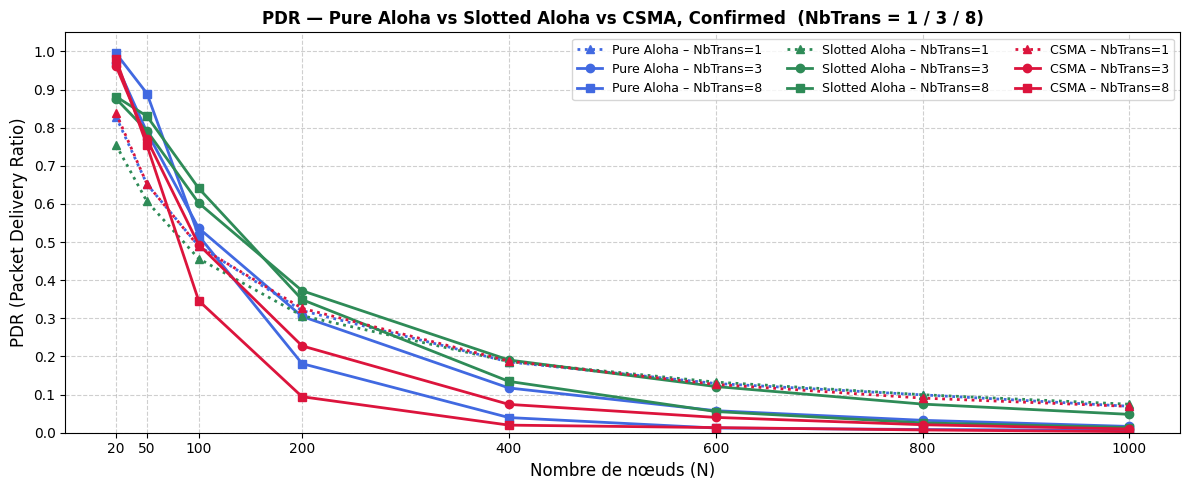

[OK] pdr_all_protocols.png sauvegardé


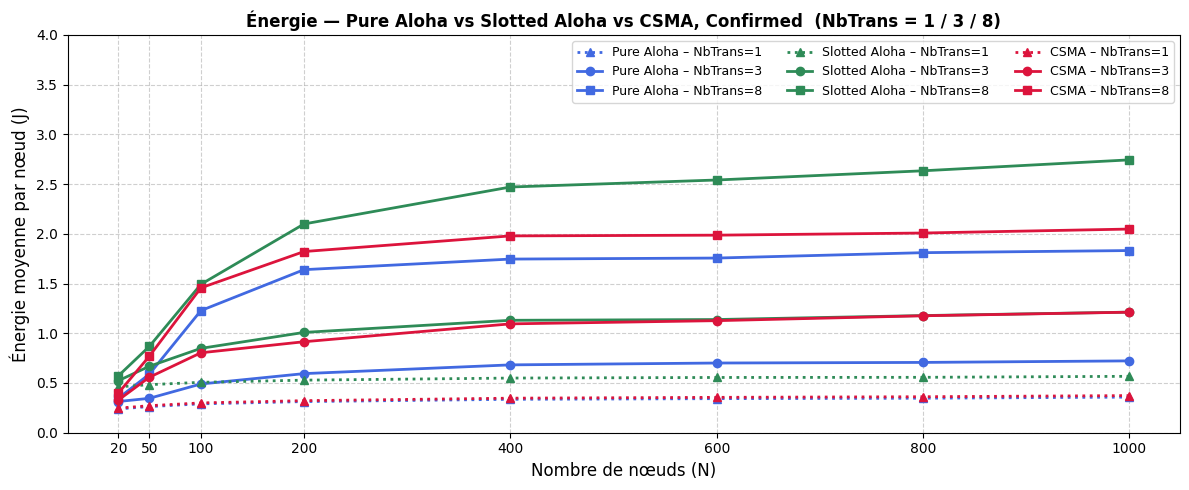

[OK] energy_all_protocols.png sauvegardé


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── Chemins ────────────────────────────────────────────────────────────────────
PATHS = {
    "pure_aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted_aloha": {
        "0retx": os.path.join(BASE, "SlottedAlohaSansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "SlottedAlohaAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionConfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionConfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Encodage visuel ────────────────────────────────────────────────────────────
# Couleur → protocole
COLORS = {
    "pure_aloha":    "royalblue",
    "slotted_aloha": "seagreen",
    "csma":          "crimson",
}

PROTO_LABELS = {
    "pure_aloha":    "Pure Aloha",
    "slotted_aloha": "Slotted Aloha",
    "csma":          "CSMA",
}

# Marqueur + linestyle → NbTrans

MARKERS    = {"0retx": "^", "2retx": "o", "7retx": "s"}
LINESTYLES = {"0retx": ":",  "2retx": "-",  "7retx": "-"}
NBTRANS_LABELS = {
    "0retx": "NbTrans=1",
    "2retx": "NbTrans=3",
    "7retx": "NbTrans=8",
}

# Génération automatique du dictionnaire de style (9 courbes)
# Ordre : par protocole puis par NbTrans → dans la légende ncol=3,
# chaque colonne regroupe un protocole
CURVES = {}
for proto in PATHS:
    for retx in ["0retx", "2retx", "7retx"]:
        key = f"{proto}_{retx}"
        CURVES[key] = dict(
            color=COLORS[proto],
            marker=MARKERS[retx],
            ls=LINESTYLES[retx],
            lw=2,
            label=f"{PROTO_LABELS[proto]} – {NBTRANS_LABELS[retx]}",
        )


# ── Helpers ────────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_pdr_confirmed(csv_path):
    """PDR = receivedAckPackets / sentPackets"""
    ack  = get_results(csv_path, "receivedAckPackets")
    sent = get_results(csv_path, "sentPackets")
    if ack.empty or sent.empty:
        return ack
    merged = ack.merge(sent, on="N", suffixes=("_ack", "_sent"))
    out = merged[["N"]].copy()
    out["value"] = merged["value_ack"] / merged["value_sent"]
    return out


def get_energy_per_node(csv_path, with_csma_energy=False):
    """Energie moyenne par noeud actif (node_idx < N)."""
    df = _load(csv_path)
    N_dict_map = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    # Fallback si le filtre module ne remonte rien
    if sub_e.empty:
        mask_e2 = df["name"] == "totalEnergyConsumed"
        sub_e = df[mask_e2][["run", "module", "value"]].rename(columns={"value": "energy"})
        if sub_e.empty:
            print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
            return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict_map)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


# ── Chargement des données ─────────────────────────────────────────────────────
pdr    = {}
energy = {}

for proto, paths in PATHS.items():
    use_csma_energy = (proto == "csma")
    for retx, path in paths.items():
        key = f"{proto}_{retx}"
        pdr[key]    = get_pdr_confirmed(path)
        energy[key] = get_energy_per_node(path, with_csma_energy=use_csma_energy)


# ── Affichage tabulaire ────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for key, df in data_dict.items():
        label = CURVES[key]["label"]
        print(f"\n--- {label} ---")
        if df is None or df.empty:
            print("  Aucune donnée")
            continue
        display = df.copy()
        display["value"] = display["value"].round(6)
        if unit:
            display["value"] = display["value"].astype(str) + f" {unit}"
        print(display.to_string(index=False))

print_scenario_tables(pdr,    "PDR (ACK / SentPackets) — Confirmed")
print_scenario_tables(energy, "Énergie moyenne par nœud — Confirmed", unit="J")


# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 5))

for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], linestyle=s["ls"],
                 label=s["label"])

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title(
    "PDR — Pure Aloha vs Slotted Aloha vs CSMA, Confirmed  (NbTrans = 1 / 3 / 8)",
    fontsize=12, fontweight="bold"
)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
# ncol=3 → 1 colonne par protocole dans la légende
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_all_protocols.png", dpi=300)
plt.show()
print("[OK] pdr_all_protocols.png sauvegardé")


# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], linestyle=s["ls"],
                 label=s["label"])

ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_title(
    "Énergie — Pure Aloha vs Slotted Aloha vs CSMA, Confirmed  (NbTrans = 1 / 3 / 8)",
    fontsize=12, fontweight="bold"
)
ax2.set_ylim(bottom=0, top=4)
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=9, ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_all_protocols.png", dpi=300)
plt.show()
print("[OK] energy_all_protocols.png sauvegardé")

/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_

[WARN] 'Total CSMA Energy' absent dans /home/hiba/omnetpp-6.0.1/samples/florasatNVArchOC/simulations/CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv — non ajouté


/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_6117/3057345796.py:67: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)



  PDR (LoRa_NS_DER) — Unconfirmed

--- Pure Aloha – NbTrans=1 ---
   N    value
  20 0.977818
  50 0.908021
 100 0.833616
 200 0.706539
 400 0.497973
 600 0.379956
 800 0.268362
1000 0.181818

--- Pure Aloha – NbTrans=3 ---
   N    value
  20 0.995770
  50 0.975432
 100 0.923969
 200 0.783842
 400 0.483433
 600 0.279600
 800 0.163007
1000 0.100095

--- Pure Aloha – NbTrans=8 ---
   N    value
  20 0.997856
  50 0.986988
 100 0.909981
 200 0.591265
 400 0.161491
 600 0.047649
 800 0.020178
1000 0.010770

--- Slotted Aloha – NbTrans=1 ---
   N    value
  20 0.888799
  50 0.843002
 100 0.782414
 200 0.680086
 400 0.513636
 600 0.392284
 800 0.299435
1000 0.226481

--- Slotted Aloha – NbTrans=3 ---
   N    value
  20 0.887800
  50 0.839201
 100 0.764860
 200 0.616023
 400 0.363504
 600 0.229626
 800 0.131154
1000 0.072238

--- Slotted Aloha – NbTrans=8 ---
   N    value
  20 0.879629
  50 0.802900
 100 0.643519
 200 0.357774
 400 0.109001
 600 0.053414
 800 0.030670
1000 0.018055

--- CSM

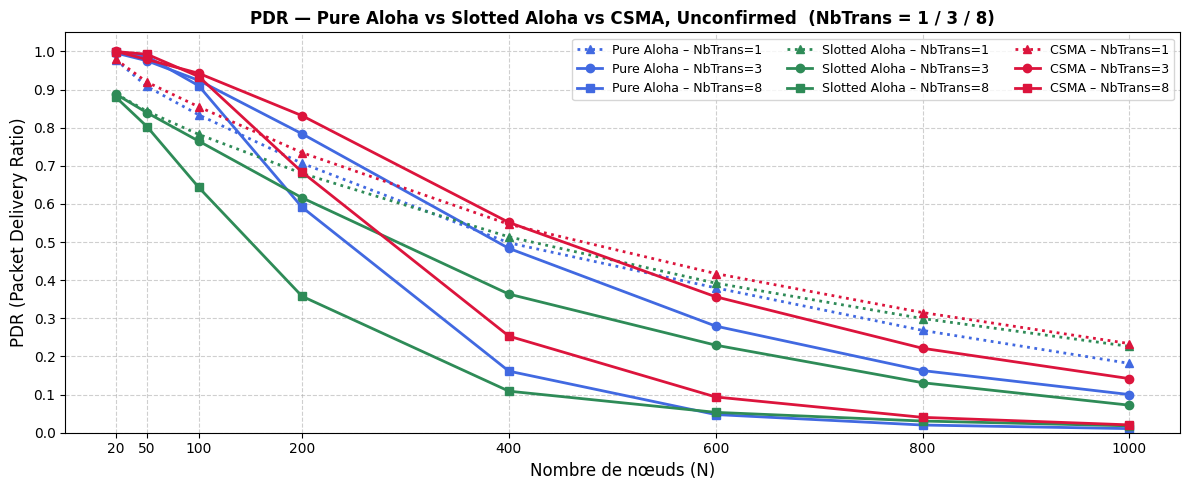

[OK] pdr_all_protocols_unconfirmed.png sauvegardé


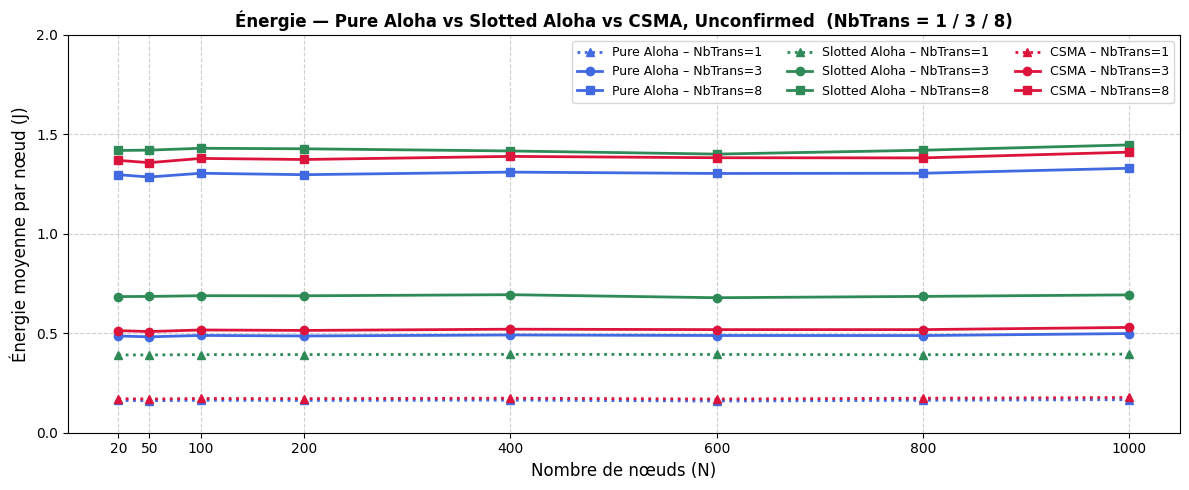

[OK] energy_all_protocols_unconfirmed.png sauvegardé


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ── Chemins ────────────────────────────────────────────────────────────────────
PATHS = {
    "pure_aloha": {
        "0retx": os.path.join(BASE, "purealohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "pureAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "slotted_aloha": {
        "0retx": os.path.join(BASE, "SlottedAlohaSansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "SlottedAlohaAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "0retx": os.path.join(BASE, "CSMASansRetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "2retx": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "7retx": os.path.join(BASE, "CSMAAvec7RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ── Encodage visuel ────────────────────────────────────────────────────────────
# Couleur → protocole
COLORS = {
    "pure_aloha":    "royalblue",
    "slotted_aloha": "seagreen",
    "csma":          "crimson",
}

PROTO_LABELS = {
    "pure_aloha":    "Pure Aloha",
    "slotted_aloha": "Slotted Aloha",
    "csma":          "CSMA",
}

# Marqueur + linestyle → NbTrans
MARKERS    = {"0retx": "^", "2retx": "o", "7retx": "s"}
LINESTYLES = {"0retx": ":",  "2retx": "-",  "7retx": "-"}
NBTRANS_LABELS = {
    "0retx": "NbTrans=1",
    "2retx": "NbTrans=3",
    "7retx": "NbTrans=8",
}

# Génération du dictionnaire de style (9 courbes)
CURVES = {}
for proto in PATHS:
    for retx in ["0retx", "2retx", "7retx"]:
        key = f"{proto}_{retx}"
        CURVES[key] = dict(
            color=COLORS[proto],
            marker=MARKERS[retx],
            ls=LINESTYLES[retx],
            lw=2,
            label=f"{PROTO_LABELS[proto]} – {NBTRANS_LABELS[retx]}",
        )


# ── Helpers ────────────────────────────────────────────────────────────────────
def _load(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df


def _N_dict(df):
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    return dict(zip(N_vals["run"], N_vals["N"]))


def get_results(csv_path, scalar_name, module_filter=None):
    df = _load(csv_path)
    N_vals = (df[df["type"] == "itervar"]
              .query("attrname == 'N'")[["run", "attrvalue"]].copy())
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] '{scalar_name}' absent dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_pdr_unconfirmed(csv_path):
    """PDR unconfirmed : LoRa_NS_DER depuis le networkServer (fallback sans filtre)."""
    der = get_results(csv_path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(csv_path, "LoRa_NS_DER")
    return der


def get_energy_per_node(csv_path, with_csma_energy=False):
    """Energie moyenne par nœud actif (node_idx < N)."""
    df = _load(csv_path)
    N_dict_map = _N_dict(df)

    mask_e = (df["name"] == "totalEnergyConsumed") & \
              df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})

    if sub_e.empty:
        # Fallback sans filtre module
        mask_e2 = df["name"] == "totalEnergyConsumed"
        sub_e = df[mask_e2][["run", "module", "value"]].rename(columns={"value": "energy"})
        if sub_e.empty:
            print(f"[WARN] totalEnergyConsumed absent dans {csv_path}")
            return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & \
                  df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if sub_c.empty:
            print(f"[WARN] 'Total CSMA Energy' absent dans {csv_path} — non ajouté")
            sub_e["total"] = sub_e["energy"]
            merged = sub_e
        else:
            merged = sub_e.merge(sub_c, on=["run", "module"], how="left")
            merged["csma_energy"] = merged["csma_energy"].fillna(0)
            merged["total"] = merged["energy"] + merged["csma_energy"]
    else:
        sub_e["total"] = sub_e["energy"]
        merged = sub_e

    merged["node_idx"] = merged["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    merged["N"] = merged["run"].map(N_dict_map)
    merged = merged.dropna(subset=["N", "node_idx"])
    merged = merged[merged["node_idx"] < merged["N"]]

    mean_per_run = merged.groupby(["run", "N"])["total"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["total"].mean().sort_values("N")
    return result.rename(columns={"total": "value"})


# ── Chargement des données ─────────────────────────────────────────────────────
pdr    = {}
energy = {}

for proto, paths in PATHS.items():
    use_csma_energy = (proto == "csma")
    for retx, path in paths.items():
        key = f"{proto}_{retx}"
        pdr[key]    = get_pdr_unconfirmed(path)
        energy[key] = get_energy_per_node(path, with_csma_energy=use_csma_energy)


# ── Affichage tabulaire ────────────────────────────────────────────────────────
def print_scenario_tables(data_dict, title, unit=""):
    print(f"\n{'='*70}")
    print(f"  {title}")
    print(f"{'='*70}")
    for key, df in data_dict.items():
        label = CURVES[key]["label"]
        print(f"\n--- {label} ---")
        if df is None or df.empty:
            print("  Aucune donnée")
            continue
        display = df.copy()
        display["value"] = display["value"].round(6)
        if unit:
            display["value"] = display["value"].astype(str) + f" {unit}"
        print(display.to_string(index=False))

print_scenario_tables(pdr,    "PDR (LoRa_NS_DER) — Unconfirmed")
print_scenario_tables(energy, "Énergie moyenne par nœud — Unconfirmed", unit="J")


# ── Figure 1 : PDR ────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(12, 5))

for key, df in pdr.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax1.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], linestyle=s["ls"],
                 label=s["label"])

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (Packet Delivery Ratio)", fontsize=12)
ax1.set_title(
    "PDR — Pure Aloha vs Slotted Aloha vs CSMA, Unconfirmed  (NbTrans = 1 / 3 / 8)",
    fontsize=12, fontweight="bold"
)
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=9, ncol=3)   # 1 colonne par protocole
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_all_protocols_unconfirmed.png", dpi=300)
plt.show()
print("[OK] pdr_all_protocols_unconfirmed.png sauvegardé")


# ── Figure 2 : Énergie ────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

for key, df in energy.items():
    if df is not None and not df.empty:
        s = CURVES[key]
        ax2.plot(df["N"], df["value"],
                 marker=s["marker"], color=s["color"],
                 linewidth=s["lw"], linestyle=s["ls"],
                 label=s["label"])

ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_title(
    "Énergie — Pure Aloha vs Slotted Aloha vs CSMA, Unconfirmed  (NbTrans = 1 / 3 / 8)",
    fontsize=12, fontweight="bold"
)
ax2.set_ylim(bottom=0, top=2)
ax2.yaxis.set_major_locator(plt.MultipleLocator(0.5))
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=9, ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_all_protocols_unconfirmed.png", dpi=300)
plt.show()
print("[OK] energy_all_protocols_unconfirmed.png sauvegardé")

/tmp/ipykernel_16478/2443548444.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_16478/2443548444.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_16478/2443548444.py:14: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_16478/2443548444.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_16478/2443548444.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_16478/2443548444.py:33: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd


--- 10B : LoRa_NS_DER ---
      N     value
0    20  0.887800
1    50  0.839201
2   100  0.764860
3   200  0.616023
4   400  0.363504
5   600  0.229626
6   800  0.131154
7  1000  0.072238

--- 28B : LoRa_NS_DER ---
      N     value
0    20  0.887200
1    50  0.833856
2   100  0.761719
3   200  0.615626
4   400  0.366439
5   600  0.225220
6   800  0.127280
7  1000  0.070637

--- 59B : LoRa_NS_DER ---
      N     value
0    20  0.883765
1    50  0.826839
2   100  0.758452
3   200  0.606358
4   400  0.362465
5   600  0.218995
6   800  0.118421
7  1000  0.068581

--- 10B : énergie par nœud (J) ---
      N     value
0    20  0.684448
1    50  0.685037
2   100  0.688730
3   200  0.688237
4   400  0.693808
5   600  0.678579
6   800  0.685288
7  1000  0.692946

--- 59B : énergie par nœud (J) ---
      N     value
0    20  1.401180
1    50  1.403388
2   100  1.429986
3   200  1.447042
4   400  1.428149
5   600  1.418766
6   800  1.459624
7  1000  1.508861

--- 28B : énergie par nœud (J) ---
 

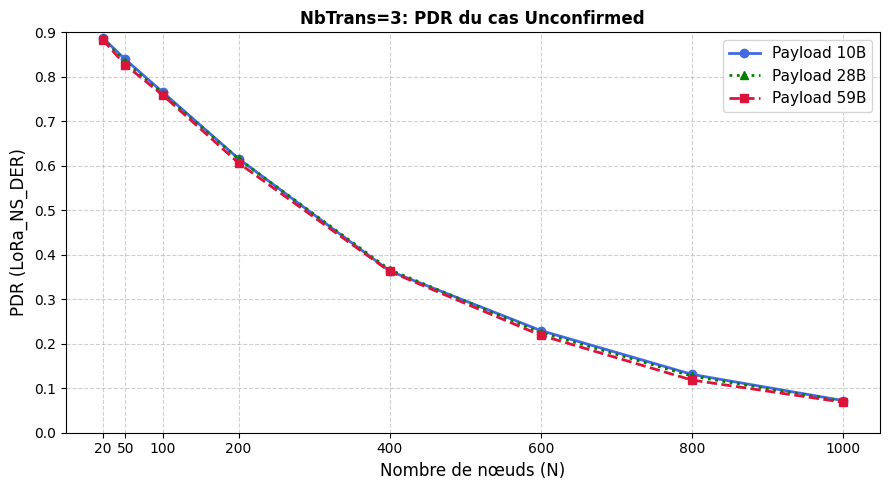

[OK] Figure sauvegardée : pdr_payload_comparison.png


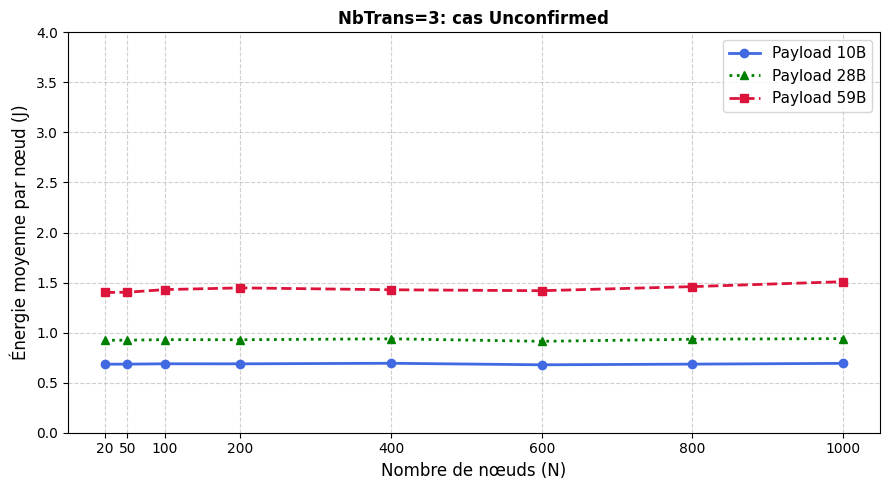

[OK] Figure sauvegardée : energy_payload_comparison.png


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

PATH_DEFAULT = os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv")
PATH_59B     = os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv")
PATH_28B     = os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv")

custom_ticks = [ 20, 50, 100, 200, 400, 600, 800, 1000]

def get_results(csv_path, scalar_name, module_filter=None):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")

def get_energy_per_node(csv_path):
    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))
    mask = (df["name"] == "totalEnergyConsumed") & \
           (df["module"].str.contains("loRaNodes", na=False))
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])
    sub["node_idx"] = sub["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub["N"] = sub["run"].map(N_dict)
    sub = sub.dropna(subset=["N", "node_idx"])
    sub = sub[sub["node_idx"] < sub["N"]]
    mean_per_run = sub.groupby(["run", "N"])["value"].mean().reset_index()
    result = mean_per_run.groupby("N", as_index=False)["value"].mean().sort_values("N")
    return result

def load_der(path):
    der = get_results(path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(path, "LoRa_NS_DER")
    return der

der_default = load_der(PATH_DEFAULT)
der_59b     = load_der(PATH_59B)
der_28b     = load_der(PATH_28B)

energy_default = get_energy_per_node(PATH_DEFAULT)
energy_59b     = get_energy_per_node(PATH_59B)
energy_28b     = get_energy_per_node(PATH_28B)

# ================================
# Affichage console
# ================================
print("\n--- 10B : LoRa_NS_DER ---")
print(der_default)

print("\n--- 28B : LoRa_NS_DER ---")
print(der_28b)

print("\n--- 59B : LoRa_NS_DER ---")
print(der_59b)

print("\n--- 10B : énergie par nœud (J) ---")
print(energy_default)
print("\n--- 59B : énergie par nœud (J) ---")
print(energy_59b)
print("\n--- 28B : énergie par nœud (J) ---")
print(energy_28b)

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

if not der_default.empty:
    ax1.plot(der_default["N"], der_default["value"],
             marker="o", color="royalblue", linewidth=2,
             label="Payload 10B")
if not der_28b.empty:
    ax1.plot(der_28b["N"], der_28b["value"],
             marker="^", color="green", linewidth=2, linestyle=":",
             label="Payload 28B")
if not der_59b.empty:
    ax1.plot(der_59b["N"], der_59b["value"],
             marker="s", color="crimson", linewidth=2, linestyle="--",
             label="Payload 59B")

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (LoRa_NS_DER)", fontsize=12)
ax1.set_title("NbTrans=3: PDR du cas Unconfirmed",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 0.9)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_payload_comparison.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : pdr_payload_comparison.png")


# ================================
# Figure 2 : Énergie — courbes par taille de payload
# ================================
fig2, ax2 = plt.subplots(figsize=(9, 5))

for df_plot, marker, color, linestyle, label in [
    (energy_default, "o", "royalblue",  "-",  "Payload 10B"),
    (energy_28b,     "^", "green",      ":",  "Payload 28B"),
    (energy_59b,     "s", "crimson", "--", "Payload 59B"),
]:
    if df_plot.empty:
        continue

    mean_val = df_plot["value"].mean()

    ax2.plot(df_plot["N"], df_plot["value"],
             marker=marker, color=color, linewidth=2, linestyle=linestyle,
             label=label)



ax2.set_ylim(0, 4)
ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_title("NbTrans=3: cas Unconfirmed", fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=11, loc="upper right")
ax2.grid(True, linestyle="--", alpha=0.6)
plt.subplots_adjust(left=0.18) 
plt.tight_layout()
plt.savefig("energy_payload_comparison.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : energy_payload_comparison.png")


/tmp/ipykernel_2079/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2079/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2079/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2079/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2079/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path)
/tmp/ipykernel_2079/1467838887.py:38: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_


--- slotted 10B : LoRa_NS_DER ---
      N     value
0    20  0.885601
1    50  0.834115
2   100  0.756436
3   200  0.601214
4   400  0.353046
5   600  0.229626
6   800  0.131154
7  1000  0.068419

--- slotted 10B : énergie par nœud (J) ---
      N     value
0    20  0.684984
1    50  0.685466
2   100  0.689343
3   200  0.688558
4   400  0.694056
5   600  0.678579
6   800  0.685288
7  1000  0.695376

--- slotted 28B : LoRa_NS_DER ---
      N     value
0    20  0.885011
1    50  0.831219
2   100  0.754899
3   200  0.604778
4   400  0.359784
5   600  0.220264
6   800  0.126312
7  1000  0.070637

--- slotted 28B : énergie par nœud (J) ---
      N     value
0    20  0.924988
1    50  0.925793
2   100  0.931207
3   200  0.929353
4   400  0.938567
5   600  0.914278
6   800  0.927457
7  1000  0.941329

--- slotted 59B : LoRa_NS_DER ---
      N     value
0    20  0.859865
1    50  0.806676
2   100  0.715776
3   200  0.567586
4   400  0.324511
5   600  0.189648
6   800  0.112583
7  1000  0.0677

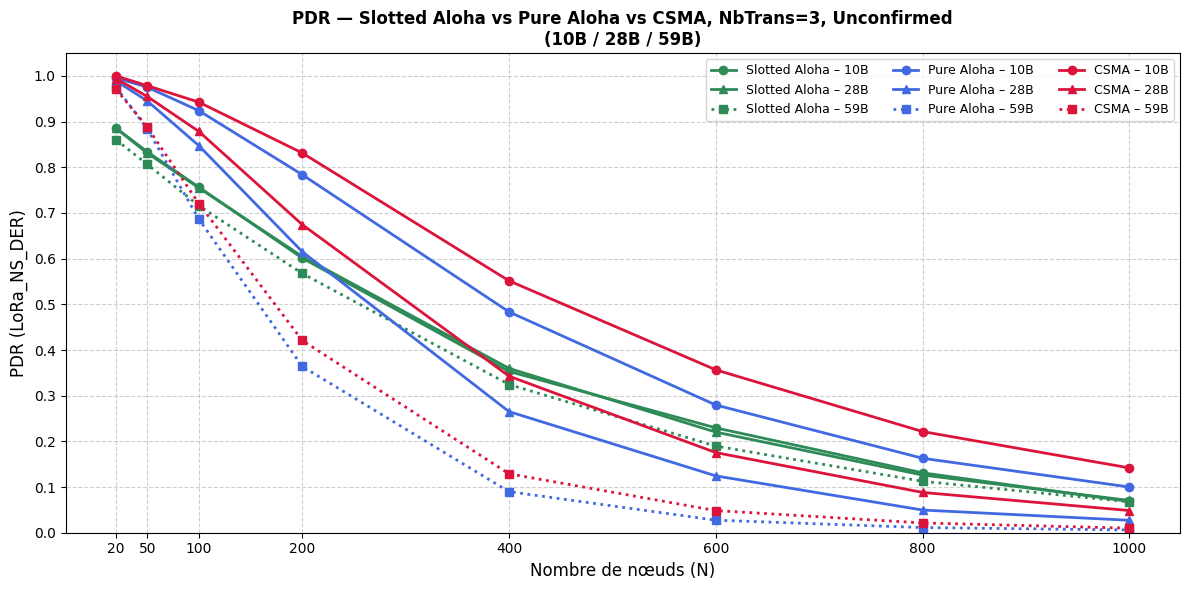

[OK] Figure sauvegardée : pdr_slotted_aloha_csma_payload.png


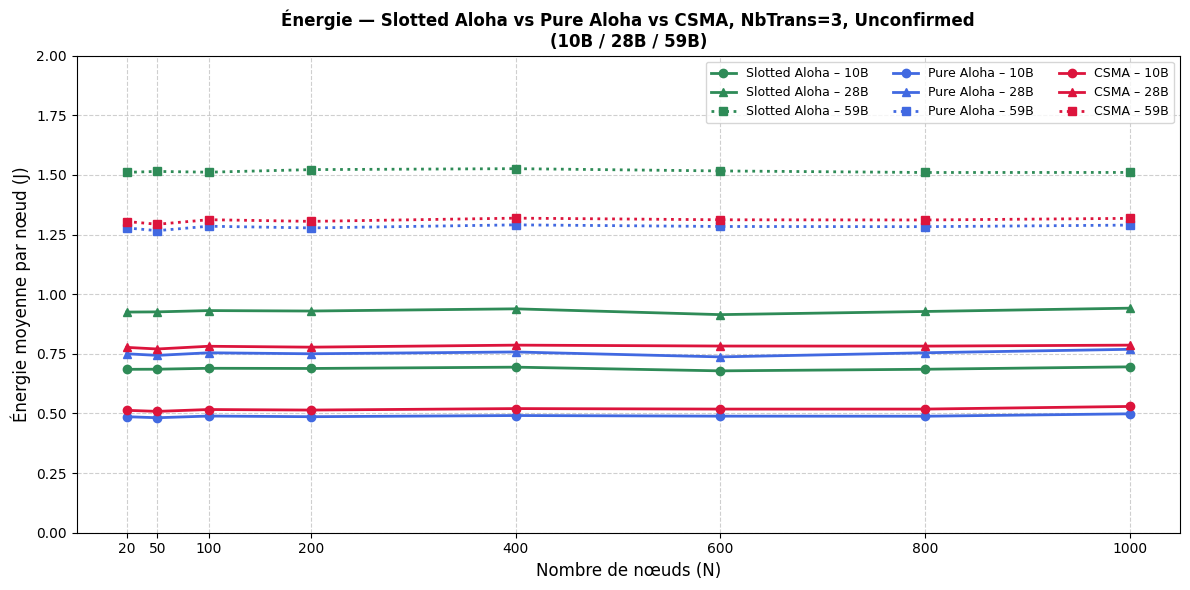

[OK] Figure sauvegardée : energy_slotted_aloha_csma_payload.png


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE = os.getcwd()

# ================================
# Chemins des CSV pour chaque protocole / payload
# ================================
PATHS = {
    "slotted": {
        "10B": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "SlottedAlohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
    "aloha": {
        "10B": os.path.join(BASE, "pureAlohaAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "purealohaAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
    "csma": {
        "10B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed/results/florasat_scalars_only.csv"),
        "28B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed28B/results/florasat_scalars_only.csv"),
        "59B": os.path.join(BASE, "CSMAAvec2RetransmissionUnconfirmed59B/results/florasat_scalars_only.csv"),
    },
}

custom_ticks = [20, 50, 100, 200, 400, 600, 800, 1000]

# ================================
# Helpers
# ================================
def get_results(csv_path, scalar_name, module_filter=None):
    if not os.path.exists(csv_path):
        print(f"[WARN] Fichier introuvable : {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")

    mask = df["name"] == scalar_name
    if module_filter:
        mask &= df["module"].str.contains(module_filter, na=False)
    sub = df[mask].copy()
    if sub.empty:
        print(f"[WARN] Aucune donnee pour '{scalar_name}' dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    per_run = sub.groupby("run")["value"].mean()
    wide = per_run.reset_index().merge(N_vals[["run", "N"]], on="run")
    return wide.groupby("N", as_index=False)["value"].mean().sort_values("N")


def get_energy_per_node(csv_path, with_csma_energy=False):
    if not os.path.exists(csv_path):
        print(f"[WARN] Fichier introuvable : {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    df = pd.read_csv(csv_path)
    for col in ["name", "module", "run"]:
        df[col] = df[col].astype(str).str.strip()
    df["value"] = pd.to_numeric(df["value"], errors="coerce")

    itervars = df[df["type"] == "itervar"]
    N_vals = itervars[itervars["attrname"] == "N"][["run", "attrvalue"]].copy()
    N_vals["N"] = pd.to_numeric(N_vals["attrvalue"], errors="coerce")
    N_dict = dict(zip(N_vals["run"], N_vals["N"]))

    mask_e = (df["name"] == "totalEnergyConsumed") & df["module"].str.contains("loRaNodes", na=False)
    sub_e = df[mask_e][["run", "module", "value"]].rename(columns={"value": "energy"})
    if sub_e.empty:
        print(f"[WARN] Aucune energie trouvee dans {csv_path}")
        return pd.DataFrame(columns=["N", "value"])

    if with_csma_energy:
        mask_c = (df["name"] == "Total CSMA Energy (J)") & df["module"].str.contains("loRaNodes", na=False)
        sub_c = df[mask_c][["run", "module", "value"]].rename(columns={"value": "csma_energy"})
        if not sub_c.empty:
            sub_e = sub_e.merge(sub_c, on=["run", "module"], how="left")
            sub_e["csma_energy"] = sub_e["csma_energy"].fillna(0)
            sub_e["energy"] = sub_e["energy"] + sub_e["csma_energy"]

    sub_e["node_idx"] = sub_e["module"].str.extract(r"loRaNodes\[(\d+)\]").astype(float)
    sub_e["N"] = sub_e["run"].map(N_dict)
    sub_e = sub_e.dropna(subset=["N", "node_idx"])
    sub_e = sub_e[sub_e["node_idx"] < sub_e["N"]]

    mean_per_run = sub_e.groupby(["run", "N"])["energy"].mean().reset_index()
    return (mean_per_run.groupby("N", as_index=False)["energy"]
            .mean().sort_values("N").rename(columns={"energy": "value"}))


def load_der(path):
    der = get_results(path, "LoRa_NS_DER", module_filter="networkServer")
    if der.empty:
        der = get_results(path, "LoRa_NS_DER")
    return der


# ================================
# Chargement des données
# ================================
PROTOCOLS = ["slotted", "aloha", "csma"]
PAYLOADS = ["10B", "28B", "59B"]

der = {
    proto: {p: load_der(PATHS[proto][p]) for p in PAYLOADS}
    for proto in PROTOCOLS
}
energy = {
    proto: {p: get_energy_per_node(PATHS[proto][p], with_csma_energy=(proto == "csma")) for p in PAYLOADS}
    for proto in PROTOCOLS
}

# ================================
# Affichage console
# ================================
for proto in PROTOCOLS:
    for p in PAYLOADS:
        print(f"\n--- {proto} {p} : LoRa_NS_DER ---")
        print(der[proto][p])
        print(f"\n--- {proto} {p} : énergie par nœud (J) ---")
        print(energy[proto][p])

# ================================
# Style visuel
# ================================
# Couleur  → payload   : bleu=10B, rouge=28B, vert=59B
# Trait    → protocole : continu=Slotted Aloha, pointillé=Pure Aloha, tirets=CSMA
# Marqueur → payload   : o=10B, ^=28B, s=59B

# Couleur = protocole
PROTO_COLOR = {
    "aloha": "royalblue",      # Pure Aloha
    "slotted": "seagreen",     # Slotted Aloha
    "csma": "crimson",         # CSMA
}

# Marqueur = payload
PAYLOAD_MARKER = {
    "10B": "o",
    "28B": "^",
    "59B": "s",
}

# Style de ligne = payload
PAYLOAD_LS = {
    "10B": "-",
    "28B": "-",
    "59B": ":",
}
PROTO_LABEL = {
    "slotted": "Slotted Aloha",
    "aloha":   "Pure Aloha",
    "csma":    "CSMA",
}

# ================================
# Figure 1 : PDR
# ================================
fig1, ax1 = plt.subplots(figsize=(12, 6))

for proto in PROTOCOLS:
    for payload in PAYLOADS:
        df = der[proto][payload]
        if df.empty:
            continue
        ax1.plot(
            df["N"], df["value"],
            color=PROTO_COLOR[proto],
            marker=PAYLOAD_MARKER[payload],
            linestyle=PAYLOAD_LS[payload],
            linewidth=2,
            label=f"{PROTO_LABEL[proto]} – {payload}"
        )

ax1.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax1.set_ylabel("PDR (LoRa_NS_DER)", fontsize=12)
ax1.set_title("PDR — Slotted Aloha vs Pure Aloha vs CSMA, NbTrans=3, Unconfirmed\n(10B / 28B / 59B)",
              fontsize=12, fontweight="bold")
ax1.set_ylim(0, 1.05)
ax1.yaxis.set_major_locator(plt.MultipleLocator(0.1))
ax1.set_xticks(custom_ticks)
ax1.legend(fontsize=9, ncol=3)
ax1.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("pdr_slotted_aloha_csma_payload.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : pdr_slotted_aloha_csma_payload.png")

# ================================
# Figure 2 : Énergie
# ================================
fig2, ax2 = plt.subplots(figsize=(12, 6))

for proto in PROTOCOLS:
    for payload in PAYLOADS:
        df = energy[proto][payload]
        if df.empty:
            continue
        ax2.plot(
            df["N"], df["value"],
            color=PROTO_COLOR[proto],
            marker=PAYLOAD_MARKER[payload],
            linestyle=PAYLOAD_LS[payload],
            linewidth=2,
            label=f"{PROTO_LABEL[proto]} – {payload}"
        )

ax2.set_xlabel("Nombre de nœuds (N)", fontsize=12)
ax2.set_ylabel("Énergie moyenne par nœud (J)", fontsize=12)
ax2.set_ylim(0, 2)
ax2.set_title("Énergie — Slotted Aloha vs Pure Aloha vs CSMA, NbTrans=3, Unconfirmed\n(10B / 28B / 59B)",
              fontsize=12, fontweight="bold")
ax2.set_xticks(custom_ticks)
ax2.legend(fontsize=9, ncol=3)
ax2.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("energy_slotted_aloha_csma_payload.png", dpi=300)
plt.show()
print("[OK] Figure sauvegardée : energy_slotted_aloha_csma_payload.png")